# Newton vs Erlatibista vs Harmonikoak — Konparaketa

Notebook honek `f_master!`-ren hiru konfigurazio konparatzen ditu ASSIST erreferentziaren aurka:
1. `physics=(gr=false, ...)` — Newton hutsa
2. `physics=(gr=true,  j2_*=false)` — Newton + zuzenketa erlatibista (Damour & Deruelle, 1985)
3. `physics=(gr=true,  j2_*=true)`  — Newton + erlatibista + harmoniko grabitatorioak (Eguzkiaren J₂, Lurraren J₂–J₄)

## 1. Paketeak eta SPICE kernelak

In [1]:
#using Pkg; Pkg.activate("..")
using GravitationSimulation
using LittleEphemeris
using SPICE
using StaticArrays
using LinearAlgebra
using Plots

In [2]:
furnsh("./data/naif0012.tls", "./data/de440.bsp")

## 2. BodyCoeffs efemerideak sortu

In [3]:
ID_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 301]

et_0 = 10593.535998938605 * 86400   # 2029-01-01
et_end = 10958.037242609542 * 86400 # 2030-01-01
time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);
Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

println("Efemerideak kargatuta.")

Efemerideak kargatuta.


## 3. Hasierako baldintzak eta parametroak

In [4]:
# Unitateen bihurketa
AU = 149597870.7   # km
DAY = 86400.0      # s

# Apophisen hasierako egoera (AU eta AU/day, heliozentrikoa)
u0_arr = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
          -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora (POSIZIOA)
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0_arr[1:3] .+= eguzkia_pos_barizentrikoa

# km eta km/s-ra bihurtu
u0_arr[1:3] .*= AU
u0_arr[4:6] .*= (AU / DAY)

# Heliozentrikotik barizentrikora (ABIADURA)
# Eguzkiaren abiadura barizentrikoa gehitu behar da!
# Sun(et_0) -> [x, y, z, vx, vy, vz] km eta km/s-tan
sun_state_0 = Sun(et_0)
u0_arr[4:6] .+= [sun_state_0[4], sun_state_0[5], sun_state_0[6]]
println("Eguzkiaren abiadura barizentrikoa (km/s): ", round.([sun_state_0[4], sun_state_0[5], sun_state_0[6]], sigdigits=4))

# Vector arrunta erabili (SVector immutablea da eta RK4-k in-place aldaketak egiten ditu)
u0 = copy(u0_arr)

# Grabitazio parametroak (km^3/s^2)
mu_S   = 1.32712440042e11
mu_E   = 398600.435
mu_M   = 4902.80
mu_Mer = 22032.09
mu_V   = 324858.59
mu_Ma  = 42828.37
mu_J   = 1.26686534e8
mu_Sat = 3.7931187e7
mu_U   = 5.793939e6
mu_N   = 6.836529e6

# Parametro egitura komuna (NAIF ID ordena erabiltzen da equations.jl-n).
# `physics` aldatuta hiru konfigurazio sortzen ditugu f_master!-rentzat.
_mus    = [mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N]
_bodies = [Sun, Earth, Moon, Mercury, Venus, Mars, Jupiter, Saturn, Uranus, Neptune]
_ids    = [10, 3, 301, 1, 2, 4, 5, 6, 7, 8]

p_newton = (mus=_mus, bodies=_bodies, ids=_ids,
    physics = (gr=false, j2_sun=false, j2_earth=false, j3_earth=false, j4_earth=false))

p_rel = (mus=_mus, bodies=_bodies, ids=_ids,
    physics = (gr=true, j2_sun=false, j2_earth=false, j3_earth=false, j4_earth=false))

p_relJ = (mus=_mus, bodies=_bodies, ids=_ids,
    physics = (gr=true, j2_sun=true, j2_earth=true, j3_earth=true, j4_earth=true))

println("Parametroak definituta. Gorputz kopurua: $(length(_mus))")
println("NAIF ID bidezko EMB -> Lurra zuzenketa funtzio barruan aktibatuta.")

Eguzkiaren abiadura barizentrikoa (km/s): [-0.0007241, 0.008341, 0.003599]
Parametroak definituta. Gorputz kopurua: 10
NAIF ID bidezko EMB -> Lurra zuzenketa funtzio barruan aktibatuta.


## 4. Integrazioa: Newton vs Erlatibista

In [5]:
# Denbora parametroak
t0 = et_0
N_samples = 10000
dt_out = (et_end - et_0) / (N_samples - 1)

# m_out handitu: RK4-ren trunkatze errorea h⁴-rekin doaz.
# 2029ko gertuketa (Apophis ~31000 km Lurretik) ondo hartzeko,
# h txikia behar da. m_out=4 → h≈788 s (handiegia); m_out=32 → h≈99 s
m_out = 32
h = dt_out / m_out

println("Integrazio parametroak:")
println("  h = $(round(h, digits=2)) s  ($(round(h/60, digits=1)) min)")
println("  m = $m_out")
println("  dt_out = $(round(dt_out, digits=2)) s")
println("  Denbora tartea: $(round((et_end - et_0)/DAY, digits=1)) egun")
println("  Pauso guztira: $(N_samples * m_out)")

# 1. Newton hutsa
println("\n▶ Newton hutsa (f_master! + gr=false) kalkulatzen...")
@time tt_newton, uu_newton = RK4(u0, t0, et_end, h, p_newton, f_master!, m_out);

# 2. Newton + Erlatibista
println("▶ Newton + Erlatibista (f_master! + gr=true) kalkulatzen...")
@time tt_rel, uu_rel = RK4(u0, t0, et_end, h, p_rel, f_master!, m_out);

# 3. Newton + Erlatibista + Harmonikoak
println("▶ Newton + Erlatibista + Harmonikoak (f_master! + gr=true + Jn) kalkulatzen...")
@time tt_J, uu_J = RK4(u0, t0, et_end, h, p_relJ, f_master!, m_out);

println("\nHiru simulazioak amaituta. Puntu kopurua: $(length(tt_newton))")

Integrazio parametroak:
  h = 98.43 s  (1.6 min)
  m = 32
  dt_out = 3149.61 s
  Denbora tartea: 364.5 egun
  Pauso guztira: 320000

▶ Newton hutsa (f_master! + gr=false) kalkulatzen...
  6.322198 seconds (186.02 M allocations: 13.585 GiB, 20.95% gc time, 10.12% compilation time)
▶ Newton + Erlatibista (f_master! + gr=true) kalkulatzen...
  5.384452 seconds (184.32 M allocations: 13.504 GiB, 21.87% gc time)
▶ Newton + Erlatibista + Harmonikoak (f_master! + gr=true + Jn) kalkulatzen...
  5.352289 seconds (184.32 M allocations: 13.504 GiB, 22.29% gc time)

Hiru simulazioak amaituta. Puntu kopurua: 10000


## 5. ASSIST erreferentzia kargatu

In [6]:
function extract_data(filename)
    data = Vector{Vector{Float64}}()
    number_regex = r"[-+]?\d*\.?\d+([eE][-+]?\d+)?"
    open(filename, "r") do file
        for line in eachline(file)
            matches = eachmatch(number_regex, line)
            row = [parse(Float64, m.match) for m in matches]
            if !isempty(row)
                push!(data, row)
            end
        end
    end
    return data
end

assist_apophis_pos = extract_data("data/apophis_pos.txt")
println("ASSIST erreferentzia kargatuta: $(length(assist_apophis_pos)) puntu")

ASSIST erreferentzia kargatuta: 10000 puntu


## 6. Erroreen kalkulua (Newton vs ASSIST, Erlatibista vs ASSIST)

In [7]:
# ASSIST datuak km-tara bihurtu (jatorriz AU-tan daude)
n_compare = min(length(tt_newton), length(assist_apophis_pos))

dist_newton = zeros(n_compare)
dist_rel = zeros(n_compare)
dist_J = zeros(n_compare)

for i in 1:n_compare
    assist_pos = assist_apophis_pos[i] .* AU
    
    diff_n = uu_newton[i][1:3] .- assist_pos
    dist_newton[i] = norm(diff_n)
    
    diff_r = uu_rel[i][1:3] .- assist_pos
    dist_rel[i] = norm(diff_r)
    
    diff_J = uu_J[i][1:3] .- assist_pos
    dist_J[i] = norm(diff_J)
end

t_egunak = (tt_newton[1:n_compare] .- tt_newton[1]) ./ DAY

println("Errore maximoa (km):")
println("  Newton:              $(round(maximum(dist_newton), digits=3))")
println("  Erlatibista:         $(round(maximum(dist_rel), digits=3))")
println("  Erlatibista + Jn:    $(round(maximum(dist_J), digits=3))")
println("\nAzken puntuko errorea (km):")
println("  Newton:              $(round(dist_newton[n_compare], digits=3))")
println("  Erlatibista:         $(round(dist_rel[n_compare], digits=3))")
println("  Erlatibista + Jn:    $(round(dist_J[n_compare], digits=3))")

Errore maximoa (km):
  Newton:              34516.453
  Erlatibista:         5215.104
  Erlatibista + Jn:    3498.7

Azken puntuko errorea (km):
  Newton:              34516.453
  Erlatibista:         5215.104
  Erlatibista + Jn:    3498.7


## 7. Grafikoak: Posizio errorea vs ASSIST

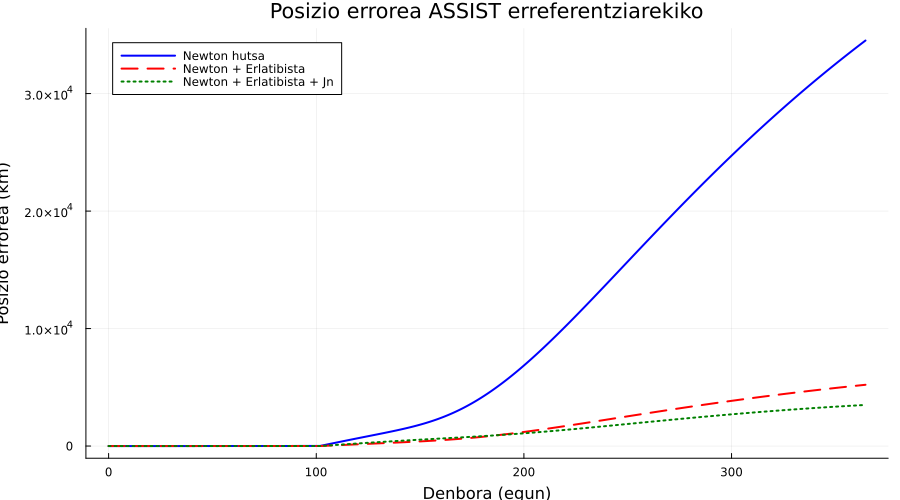

In [8]:
plot(t_egunak, dist_newton,
    label="Newton hutsa", color=:blue, lw=2,
    xlabel="Denbora (egun)",
    ylabel="Posizio errorea (km)",
    title="Posizio errorea ASSIST erreferentziarekiko",
    legend=:topleft, size=(900, 500))

plot!(t_egunak, dist_rel,
    label="Newton + Erlatibista", color=:red, lw=2, linestyle=:dash)

plot!(t_egunak, dist_J,
    label="Newton + Erlatibista + Jn", color=:green, lw=2, linestyle=:dot)

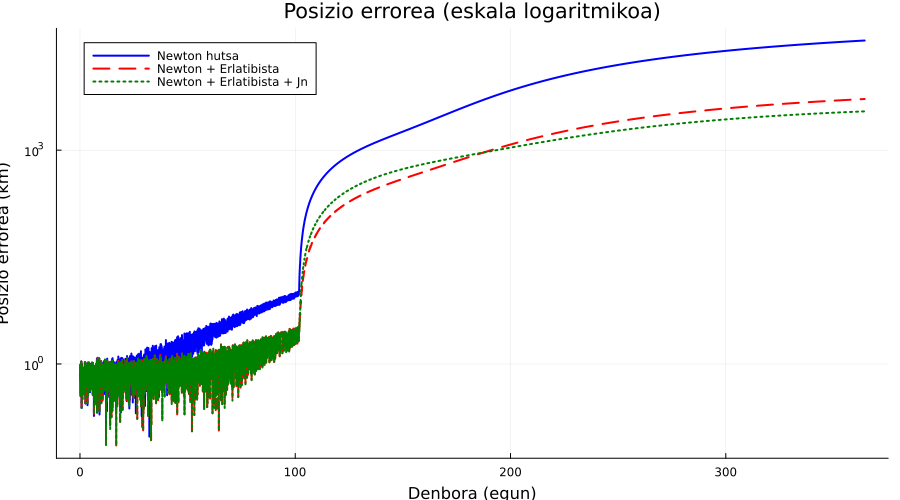

In [9]:
plot(t_egunak, dist_newton,
    label="Newton hutsa", color=:blue, lw=2,
    xlabel="Denbora (egun)",
    ylabel="Posizio errorea (km)",
    title="Posizio errorea (eskala logaritmikoa)",
    legend=:topleft, yscale=:log10, size=(900, 500))

plot!(t_egunak, dist_rel,
    label="Newton + Erlatibista", color=:red, lw=2, linestyle=:dash)

plot!(t_egunak, dist_J,
    label="Newton + Erlatibista + Jn", color=:green, lw=2, linestyle=:dot)

## 8. Bi soluzioen arteko diferentzia (Newton vs Erlatibista)

In [10]:
# Hiru soluzioen arteko diferentziak
n_puntuak = length(tt_newton)
dist_newton_vs_rel = zeros(n_puntuak)
dist_newton_vs_J = zeros(n_puntuak)
dist_rel_vs_J = zeros(n_puntuak)

for i in 1:n_puntuak
    dist_newton_vs_rel[i] = norm(uu_rel[i][1:3] .- uu_newton[i][1:3])
    dist_newton_vs_J[i] = norm(uu_J[i][1:3] .- uu_newton[i][1:3])
    dist_rel_vs_J[i] = norm(uu_J[i][1:3] .- uu_rel[i][1:3])
end

t_egunak_guztiak = (tt_newton .- tt_newton[1]) ./ DAY

plot(t_egunak_guztiak, dist_newton_vs_rel,
    label="|Erlatibista - Newton|", color=:purple, lw=2,
    xlabel="Denbora (egun)",
    ylabel="Distantzia (km)",
    title="Ereduen arteko diferentziak posizioan",
    legend=:topleft, size=(900, 500))

plot!(t_egunak_guztiak, dist_newton_vs_J,
    label="|Erlatibista+Jn - Newton|", color=:orange, lw=2, linestyle=:dash)

plot!(t_egunak_guztiak, dist_rel_vs_J,
    label="|Erlatibista+Jn - Erlatibista| (Jn eragina)", color=:green, lw=2, linestyle=:dot)

println("Azken puntuan:")
println("  Erlatibistateak aldatzen duena:    $(round(dist_newton_vs_rel[end], digits=3)) km")
println("  Erlat.+Jn-k aldatzen duena:        $(round(dist_newton_vs_J[end], digits=3)) km")
println("  Harmonikoen eragin hutsa (Jn):     $(round(dist_rel_vs_J[end], digits=3)) km")

Azken puntuan:
  Erlatibistateak aldatzen duena:    29322.119 km
  Erlat.+Jn-k aldatzen duena:        31122.17 km
  Harmonikoen eragin hutsa (Jn):     1831.966 km


## 9. Ardatzeko errorea (X, Y, Z)

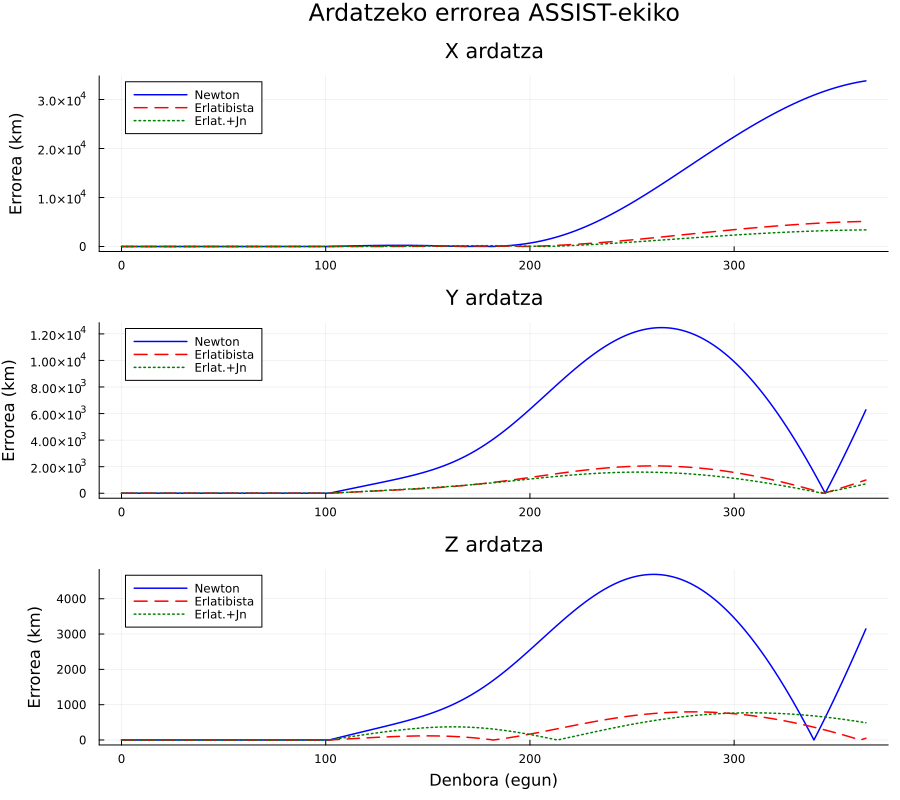

In [11]:
err_newton_x = zeros(n_compare)
err_newton_y = zeros(n_compare)
err_newton_z = zeros(n_compare)
err_rel_x = zeros(n_compare)
err_rel_y = zeros(n_compare)
err_rel_z = zeros(n_compare)
err_J_x = zeros(n_compare)
err_J_y = zeros(n_compare)
err_J_z = zeros(n_compare)

for i in 1:n_compare
    assist_pos = assist_apophis_pos[i] .* AU
    err_newton_x[i] = abs(uu_newton[i][1] - assist_pos[1])
    err_newton_y[i] = abs(uu_newton[i][2] - assist_pos[2])
    err_newton_z[i] = abs(uu_newton[i][3] - assist_pos[3])
    err_rel_x[i] = abs(uu_rel[i][1] - assist_pos[1])
    err_rel_y[i] = abs(uu_rel[i][2] - assist_pos[2])
    err_rel_z[i] = abs(uu_rel[i][3] - assist_pos[3])
    err_J_x[i] = abs(uu_J[i][1] - assist_pos[1])
    err_J_y[i] = abs(uu_J[i][2] - assist_pos[2])
    err_J_z[i] = abs(uu_J[i][3] - assist_pos[3])
end

p1 = plot(t_egunak, err_newton_x, label="Newton", lw=1.5, color=:blue)
plot!(p1, t_egunak, err_rel_x, label="Erlatibista", lw=1.5, color=:red, linestyle=:dash)
plot!(p1, t_egunak, err_J_x, label="Erlat.+Jn", lw=1.5, color=:green, linestyle=:dot)
ylabel!(p1, "Errorea (km)")
title!(p1, "X ardatza")

p2 = plot(t_egunak, err_newton_y, label="Newton", lw=1.5, color=:blue)
plot!(p2, t_egunak, err_rel_y, label="Erlatibista", lw=1.5, color=:red, linestyle=:dash)
plot!(p2, t_egunak, err_J_y, label="Erlat.+Jn", lw=1.5, color=:green, linestyle=:dot)
ylabel!(p2, "Errorea (km)")
title!(p2, "Y ardatza")

p3 = plot(t_egunak, err_newton_z, label="Newton", lw=1.5, color=:blue)
plot!(p3, t_egunak, err_rel_z, label="Erlatibista", lw=1.5, color=:red, linestyle=:dash)
plot!(p3, t_egunak, err_J_z, label="Erlat.+Jn", lw=1.5, color=:green, linestyle=:dot)
ylabel!(p3, "Errorea (km)")
xlabel!(p3, "Denbora (egun)")
title!(p3, "Z ardatza")

plot(p1, p2, p3, layout=(3, 1), size=(900, 800),
     plot_title="Ardatzeko errorea ASSIST-ekiko")

## 10. Hobekuntza faktorea

In [13]:
# Hobekuntza ratioa: Newton errorea / Eredu errorea
# >1 bada, eredu berriak hobeto egiten du
hobekuntza_rel = dist_newton ./ max.(dist_rel, 1e-15)
hobekuntza_J = dist_newton ./ max.(dist_J, 1e-15)

plot(t_egunak, hobekuntza_rel,
    label="Erlatibista vs Newton", color=:red, lw=2,
    xlabel="Denbora (egun)",
    ylabel="err_Newton / err_Eredua",
    title="Hobekuntza faktorea (Newton-ekiko)",
    legend=:topleft, size=(900, 500))

plot!(t_egunak, hobekuntza_J,
    label="Erlat.+Jn vs Newton", color=:green, lw=2, linestyle=:dash)

hline!([1.0], color=:black, linestyle=:dot, label="Faktore = 1 (berdina)")

println("Batezbesteko hobekuntza faktorea:")
println("  Erlatibista:      $(round(sum(hobekuntza_rel)/length(hobekuntza_rel), digits=2))x")
println("  Erlat. + Jn:      $(round(sum(hobekuntza_J)/length(hobekuntza_J), digits=2))x")
println("Azken puntuan:")
println("  Erlatibista:      $(round(hobekuntza_rel[end], digits=2))x")
println("  Erlat. + Jn:      $(round(hobekuntza_J[end], digits=2))x")

Batezbesteko hobekuntza faktorea:
  Erlatibista:      4.86x
  Erlat. + Jn:      5.69x
Azken puntuan:
  Erlatibista:      6.62x
  Erlat. + Jn:      9.87x


## 11. Laburpen taula

In [14]:
using Statistics

println("="^75)
println("  NEWTON vs ERLATIBISTA vs HARMONIKOAK — LABURPENA")
println("="^75)
println()
println("Konparatutako puntuak: $n_compare")
println("Denbora tartea: $(round(t_egunak[end], digits=1)) egun")
println()
println("                         Newton        Erlatibista   Erlat.+Jn")
println("-"^75)
println("Errore max (km):     $(lpad(round(maximum(dist_newton), sigdigits=4), 12))  $(lpad(round(maximum(dist_rel), sigdigits=4), 12))  $(lpad(round(maximum(dist_J), sigdigits=4), 12))")
println("Errore batezb (km):  $(lpad(round(mean(dist_newton), sigdigits=4), 12))  $(lpad(round(mean(dist_rel), sigdigits=4), 12))  $(lpad(round(mean(dist_J), sigdigits=4), 12))")
println("Azken puntua (km):   $(lpad(round(dist_newton[end], sigdigits=4), 12))  $(lpad(round(dist_rel[end], sigdigits=4), 12))  $(lpad(round(dist_J[end], sigdigits=4), 12))")
println("-"^75)
println("Ereduen arteko diferentziak azken puntuan:")
println("  Erlatibistaren eragina:             $(round(dist_newton_vs_rel[end], digits=3)) km")
println("  Erlatibista + Harmonikoen eragina:  $(round(dist_newton_vs_J[end], digits=3)) km")
println("  Harmonikoen eragin hutsa:           $(round(dist_rel_vs_J[end], digits=3)) km")
println("="^75)

  NEWTON vs ERLATIBISTA vs HARMONIKOAK — LABURPENA

Konparatutako puntuak: 10000
Denbora tartea: 364.5 egun

                         Newton        Erlatibista   Erlat.+Jn
---------------------------------------------------------------------------
Errore max (km):          34520.0        5215.0        3499.0
Errore batezb (km):       10240.0        1628.0        1217.0
Azken puntua (km):        34520.0        5215.0        3499.0
---------------------------------------------------------------------------
Ereduen arteko diferentziak azken puntuan:
  Erlatibistaren eragina:             29322.119 km
  Erlatibista + Harmonikoen eragina:  31122.17 km
  Harmonikoen eragin hutsa:           1831.966 km


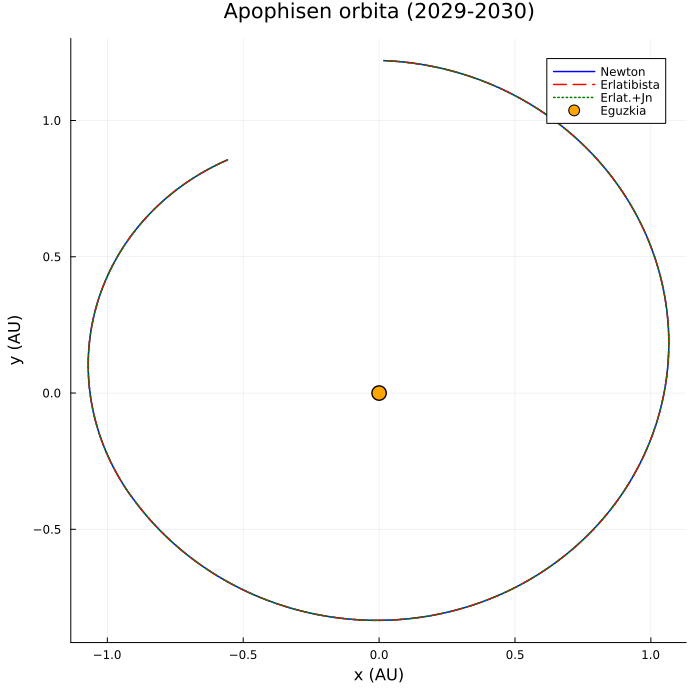

LoadError: UndefVarError: `Earth_bary` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [15]:
# ============================================================
# 12. Trajektoria-konparaketa grafikoak
# ============================================================

# --- Laguntzaileak ---
get_x(data) = [p[1] for p in data]
get_y(data) = [p[2] for p in data]
get_z(data) = [p[3] for p in data]

# --- A) Orbita osoa (AU-tan) ---
p_orbit = plot(
    get_x(uu_newton) ./ AU, get_y(uu_newton) ./ AU,
    label="Newton", lw=1.5, color=:blue,
    xlabel="x (AU)", ylabel="y (AU)",
    title="Apophisen orbita (2029-2030)",
    aspect_ratio=:equal, size=(700, 700), legend=:topright)
plot!(p_orbit,
    get_x(uu_rel) ./ AU, get_y(uu_rel) ./ AU,
    label="Erlatibista", lw=1.5, color=:red, linestyle=:dash)
plot!(p_orbit,
    get_x(uu_J) ./ AU, get_y(uu_J) ./ AU,
    label="Erlat.+Jn", lw=1.5, color=:green, linestyle=:dot)

# Eguzkia markatu
scatter!(p_orbit, [0], [0], label="Eguzkia", color=:orange, markersize=8)

display(p_orbit)

# --- B) Gertuketa: Lurrarekiko distantzia ---
# Lurraren posizioa kalkulu bakoitzean
n_p = length(tt_newton)
dist_lurra_newton = zeros(n_p)
dist_lurra_rel = zeros(n_p)
dist_lurra_J = zeros(n_p)

for i in 1:n_p
    earth_pos = Earth_bary(tt_newton[i])
    dist_lurra_newton[i] = norm(uu_newton[i][1:3] .- [earth_pos[1], earth_pos[2], earth_pos[3]])
    dist_lurra_rel[i]    = norm(uu_rel[i][1:3] .- [earth_pos[1], earth_pos[2], earth_pos[3]])
    dist_lurra_J[i]      = norm(uu_J[i][1:3] .- [earth_pos[1], earth_pos[2], earth_pos[3]])
end

t_days = (tt_newton .- tt_newton[1]) ./ DAY

p_close = plot(t_days, dist_lurra_newton ./ 1e3,
    label="Newton", lw=2, color=:blue,
    xlabel="Denbora (egun)", ylabel="Distantzia Lurretik (×10³ km)",
    title="Apophisen distantzia Lurretik",
    legend=:topright, size=(900, 500))
plot!(p_close, t_days, dist_lurra_rel ./ 1e3,
    label="Erlatibista", lw=2, color=:red, linestyle=:dash)
plot!(p_close, t_days, dist_lurra_J ./ 1e3,
    label="Erlat.+Jn", lw=2, color=:green, linestyle=:dot)
hline!(p_close, [6378.137 / 1e3], label="Lurraren erradioa", color=:brown, linestyle=:dot)

display(p_close)

# --- C) Gertuketa zoom: Lurrekiko distantzia minimoa ---
# Bilatu gertuketa-unea
_, idx_min = findmin(dist_lurra_J)
# ±10 egun inguruak
rng = max(1, idx_min - 300):min(n_p, idx_min + 300)

p_zoom = plot(t_days[rng], dist_lurra_newton[rng],
    label="Newton", lw=2, color=:blue,
    xlabel="Denbora (egun)", ylabel="Distantzia Lurretik (km)",
    title="Gertuketa fasea (zoom)",
    legend=:topright, size=(900, 500))
plot!(p_zoom, t_days[rng], dist_lurra_rel[rng],
    label="Erlatibista", lw=2, color=:red, linestyle=:dash)
plot!(p_zoom, t_days[rng], dist_lurra_J[rng],
    label="Erlat.+Jn", lw=2, color=:green, linestyle=:dot)

display(p_zoom)

println("Distantzia minimoa Lurretik:")
println("  Newton:       $(round(minimum(dist_lurra_newton), digits=1)) km")
println("  Erlatibista:  $(round(minimum(dist_lurra_rel), digits=1)) km")
println("  Erlat.+Jn:    $(round(minimum(dist_lurra_J), digits=1)) km")
println("  (Benetakoa ≈ 31,600 km)")